In [1]:
import os
import numpy as np
import kagglehub
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
# =====================================================
# CONFIG
# =====================================================

KAGGLE_DATASET = "navoneel/brain-mri-images-for-brain-tumor-detection"
IMG_SIZE = 32   # resize target

NUM_FILTERS = 4
KERNEL_SIZE = 3
POOL_SIZE = 2

LEARNING_RATE = 0.001
EPOCHS = 30

TEST_SIZE = 0.2
RANDOM_STATE = 42   # train/test split seed
RANDOM_SEED = 42     # weight init / framework seed

np.random.seed(RANDOM_SEED)

In [3]:

# =============
# Load Data
# =============

dataset_path = kagglehub.dataset_download(KAGGLE_DATASET)


def load_folder(folder, label):
    images, labels = [], []
    for fname in os.listdir(folder):
        try:
            img = Image.open(os.path.join(folder, fname)).convert("L").resize((IMG_SIZE, IMG_SIZE))
        except Exception:
            continue
        images.append(np.array(img, dtype=np.float64))
        labels.append(label)
    return images, labels


yes_images, yes_labels = load_folder(os.path.join(dataset_path, "yes"), 1)
no_images, no_labels = load_folder(os.path.join(dataset_path, "no"), 0)

X = np.array(yes_images + no_images)                     # (N, 32, 32)
y = np.array(yes_labels + no_labels).reshape(-1, 1)       # (N, 1)
print(X.shape, y.shape)

n_pos = int(y.sum())
print(f"Tumor (1):    {n_pos} ({n_pos/len(y)*100:.1f}%)   No tumor (0): {len(y)-n_pos} ({100-n_pos/len(y)*100:.1f}%)")
# stratified split below keeps this ratio consistent across train/test.

100%|██████████| 15.1M/15.1M [00:00<00:00, 57.0MB/s]

Extracting files...


(253, 32, 32) (253, 1)
Tumor (1):    155 (61.3%)   No tumor (0): 98 (38.7%)


In [4]:
# ==============================
# Train/Test Split + Scaling
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(len(X_train), -1)).reshape(-1, IMG_SIZE, IMG_SIZE)
X_test = scaler.transform(X_test.reshape(len(X_test), -1)).reshape(-1, IMG_SIZE, IMG_SIZE)


In [5]:
# ==========================================================================
# CELL 4 — Scratch CNN: parameters + forward/backward functions
# ==========================================================================

conv_out = IMG_SIZE - KERNEL_SIZE + 1              # 30 (valid conv)
pool_out = conv_out // POOL_SIZE                   # 15
flat_size = pool_out * pool_out * NUM_FILTERS       # 900

Wc = np.random.randn(NUM_FILTERS, KERNEL_SIZE, KERNEL_SIZE) * 0.1
bc = np.zeros((NUM_FILTERS, 1))
Wd = np.random.randn(1, flat_size) * 0.1
by_d = np.zeros((1, 1))


def conv_forward(X, W, b):
    """X: (H,W). W: (f,k,k). b: (f,1). Returns Z, A=relu(Z), both (out,out,f)."""
    f, k, _ = W.shape
    out = X.shape[0] - k + 1
    Z = np.zeros((out, out, f))
    for i in range(out):
        for j in range(out):
            patch = X[i:i + k, j:j + k]              # input region feeding this output pixel
            Z[i, j] = np.tensordot(W, patch, axes=([1, 2], [0, 1])) + b[:, 0]
    return Z, np.maximum(Z, 0)


def conv_backward(dZ, X, W):
    """dZ: (out,out,f). X: original input image feeding this conv. Returns dW, db."""
    f, k, _ = W.shape
    out = dZ.shape[0]
    dW = np.zeros_like(W)
    db = dZ.sum(axis=(0, 1)).reshape(-1, 1)
    for i in range(out):
        for j in range(out):
            patch = X[i:i + k, j:j + k]               # the INPUT patch, not the conv's own output
            dW += dZ[i, j].reshape(f, 1, 1) * patch    # outer product, summed over i,j
    return dW, db


def pool_forward(A, size):
    """A: (out,out,f) post-relu conv activation. Returns P and per-window argmax (row,col)."""
    out, _, f = A.shape
    p_out = out // size
    P = np.zeros((p_out, p_out, f))
    argmax = np.zeros((p_out, p_out, f, 2), dtype=int)
    for i in range(p_out):
        for j in range(p_out):
            window = A[i * size:i * size + size, j * size:j * size + size, :]  # (size,size,f)
            flat = window.reshape(-1, f)
            idx = flat.argmax(axis=0)                  # (f,)
            P[i, j] = flat[idx, np.arange(f)]
            argmax[i, j] = np.column_stack(np.unravel_index(idx, (size, size)))
    return P, argmax


def pool_backward(dP, A_shape, argmax, size):
    """Routes gradient back only to each window's max location."""
    dA = np.zeros(A_shape)
    p_out, _, f = dP.shape
    for i in range(p_out):
        for j in range(p_out):
            for c in range(f):
                di, dj = argmax[i, j, c]
                dA[i * size + di, j * size + dj, c] += dP[i, j, c]
    return dA


def dense_forward(F, W, b):
    Z = W @ F + b
    return Z, 1 / (1 + np.exp(-Z))


def dense_backward(dZ, F, W):
    return dZ @ F.T, dZ, W.T @ dZ  # dW, db, dF


def forward_pass(Xn):
    """Full forward pass for one image. Returns everything backward() needs, plus A2."""
    Z1, A1 = conv_forward(Xn, Wc, bc)
    P1, argmax = pool_forward(A1, POOL_SIZE)
    F = P1.reshape(-1, 1)
    Z2, A2 = dense_forward(F, Wd, by_d)
    return A1, P1, argmax, F, A2

In [6]:
# ==============
# Training
# ==============

loss_history = []

for epoch in range(EPOCHS):
    total_loss = 0

    for n in range(len(X_train)):
        Xn = X_train[n]
        target = y_train[n].reshape(1, 1)

        A1, P1, argmax, F, A2 = forward_pass(Xn)

        eps = 1e-8
        a = np.clip(A2, eps, 1 - eps)
        total_loss += -(target * np.log(a) + (1 - target) * np.log(1 - a)).sum()

        # sigmoid + BCE combine to this clean form (same role as dy = y_hat - target in the RNN/LSTM)
        dZ2 = A2 - target
        dWd, dbd, dF = dense_backward(dZ2, F, Wd)

        dP1 = dF.reshape(P1.shape)
        dA1 = pool_backward(dP1, A1.shape, argmax, POOL_SIZE)
        dZ1 = dA1 * (A1 > 0)  # A1 = relu(Z1), so (A1 > 0) == (Z1 > 0)

        dWc, dbc = conv_backward(dZ1, Xn, Wc)

        Wd -= LEARNING_RATE * dWd
        by_d -= LEARNING_RATE * dbd
        Wc -= LEARNING_RATE * dWc
        bc -= LEARNING_RATE * dbc

    loss_history.append(total_loss)
    if epoch % 5 == 0:
        print(f"Epoch {epoch:4d}  Loss = {total_loss/len(X_train):.6f}")

Epoch    0  Loss = 0.635855
Epoch    5  Loss = 0.484921
Epoch   10  Loss = 0.433557
Epoch   15  Loss = 0.391452
Epoch   20  Loss = 0.353240
Epoch   25  Loss = 0.315156


In [7]:
# =====================
# CELL 6 — Testing
# =====================

predictions = np.array([
    1 if forward_pass(Xn)[-1][0, 0] >= 0.5 else 0
    for Xn in X_test
]).reshape(-1, 1)

acc = accuracy_score(y_test, predictions)
print(f"Test Accuracy : {acc:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

Test Accuracy : 0.7843
Confusion Matrix:
[[13  7]
 [ 4 27]]


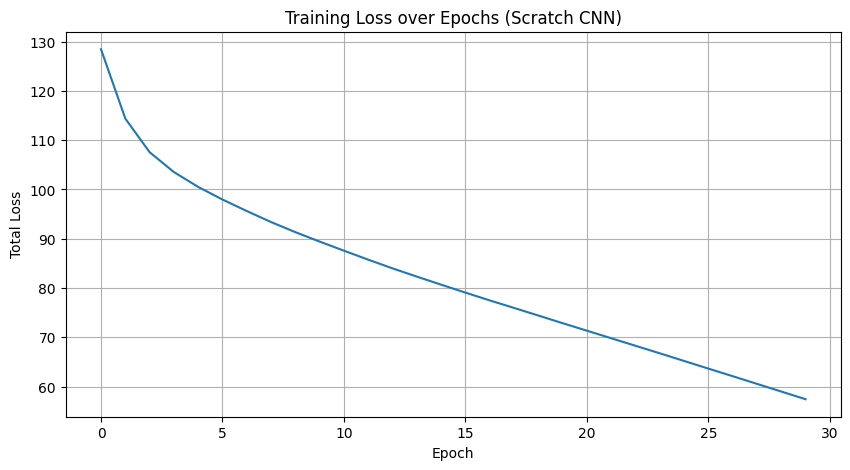

In [8]:
# ==========================================================================
# CELL 7 — Scratch CNN: loss curve
# ==========================================================================

plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training Loss over Epochs (Scratch CNN)")
plt.grid(True)
plt.show()

In [13]:
# ============================================================ #
# ==================  USING TENSORFLOW  ===================== #
# ============================================================ #

import tensorflow as tf

tf.random.set_seed(RANDOM_SEED)

# Conv2D expects a channel dimension: (N, 32, 32, 1)
X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

# Conv2D + MaxPooling2D + Flatten + Dense(sigmoid) mirrors
# conv_forward -> pool_forward -> flatten -> dense_forward in the scratch version.
model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),
    tf.keras.layers.Conv2D(NUM_FILTERS, KERNEL_SIZE, activation="relu"),
    tf.keras.layers.MaxPooling2D(POOL_SIZE),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

# Adam instead of plain SGD -- converges far more reliably than vanilla SGD
# at this learning rate; the manual version uses SGD since it's hand-derived.
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss="binary_crossentropy")

In [10]:
# ================
# Training
# ================

# batch_size=1 = update weights after every sample, same as the manual
# per-sample loop in the scratch version.
history = model.fit(X_train_cnn, y_train, epochs=EPOCHS, batch_size=1, verbose=0)

for epoch in range(0, EPOCHS, 5):
    print(f"Epoch {epoch:4d}  Loss = {history.history['loss'][epoch]:.6f}")

Epoch    0  Loss = 0.589156
Epoch    5  Loss = 0.273338
Epoch   10  Loss = 0.126536
Epoch   15  Loss = 0.056996
Epoch   20  Loss = 0.024616
Epoch   25  Loss = 0.011161


In [11]:
# =============
# Testing
# =============

predictions = (model.predict(X_test_cnn, verbose=0) >= 0.5).astype(int)

acc = accuracy_score(y_test, predictions)
print(f"Test Accuracy : {acc:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

Test Accuracy : 0.8235
Confusion Matrix:
[[16  4]
 [ 5 26]]


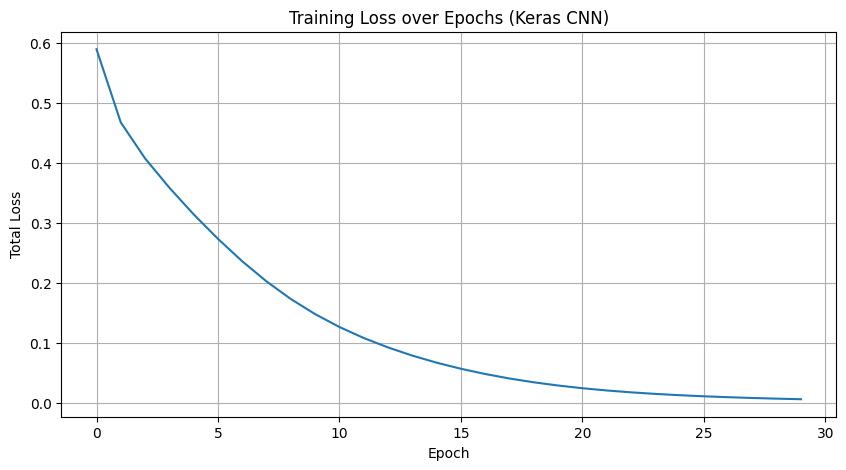

In [12]:
# ==========================================================================
# Loss curve
# ==========================================================================

plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Training Loss over Epochs (Keras CNN)")
plt.grid(True)
plt.show()